In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Raw Dataset.csv')

In [3]:
df.shape

(101, 9)

In [4]:
df.columns

Index(['Gender ', 'Age ', 'What social media platforms do you use most?',
       'On average, how many hours per day do you spend on social media?  (numeric values only, ex. 5)',
       'Mental Well-being (Dependent Variable)Please indicate how much you agree or disagree with the following statements based on your experience over the past week.\nRating Scale:1 = Strongly Disagree2 = Di',
       'Mental Well-being (Dependent Variable)Please indicate how much you agree or disagree with the following statements based on your experience over the past week.\nRating Scale:1 = Strongly Disagree2 = Di1',
       'Mental Well-being (Dependent Variable)Please indicate how much you agree or disagree with the following statements based on your experience over the past week.\nRating Scale:1 = Strongly Disagree2 = Di2',
       'Mental Well-being (Dependent Variable)Please indicate how much you agree or disagree with the following statements based on your experience over the past week.\nRating Scale:1

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 9 columns):
 #   Column                                                                                                                                                                                                     Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                     --------------  ----- 
 0   Gender                                                                                                                                                                                                     101 non-null    object
 1   Age                                                                                                                                                                                                   

In [6]:
df.describe()

,Age,"On average, how many hours per day do you spend on social media? (numeric values only, ex. 5)"
count,101.000000,101.000000
mean,20.069307,6.613861
std,0.951393,1.959440
min,18.000000,3.000000
25%,19.000000,5.000000
50%,20.000000,6.000000
75%,21.000000,8.000000
max,23.000000,15.000000


In [7]:
df.columns = [
    "gender",
    "age",
    "platforms",
    "hours",
    "q1",
    "q2",
    "q3",
    "q4",
    "q5"
]

df.head()

,gender,age,platforms,hours,q1,q2,q3,q4,q5
0,Male,21,Youtube;,7,Strongly Di,Neutral,Strongly Agree,Agree,Disagree
1,Male,20,Instagram;Tiktok,5,Agree,Neutral,Agree,Neutral,Strongly Agree
2,Female,20,Tiktok;Facebook;Instagram,5,Neutral,Neutral,Strongly Agree,Agree,Agree
3,Male,19,Youtube,5,Neutral,Neutral,Strongly Agree,Agree,Neutral
4,Male,20,Facebook;Youtube;X/Twitter;Instagram;Reddit,4,Agree,Agree,Agree,Strongly Agree,Neutral


In [8]:
df.isnull().sum()

gender       0
age          0
platforms    0
hours        0
q1           0
q2           0
q3           0
q4           0
q5           0
dtype: int64

In [9]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.strip()

In [10]:
legend_mapping = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5
}

for col in ["q1","q2","q3","q4","q5"]:
    df[col] = df[col].map(legend_mapping)

In [11]:
df.isnull().sum()

gender       0
age          0
platforms    0
hours        0
q1           1
q2           0
q3           0
q4           0
q5           0
dtype: int64

In [12]:
df = df.dropna()

In [13]:
df.isnull().sum()

gender       0
age          0
platforms    0
hours        0
q1           0
q2           0
q3           0
q4           0
q5           0
dtype: int64

In [ ]:
df["wellbeing_score"] = df[["q1","q2","q3","q4","q5"]].sum(axis=1)

In [15]:
df.head()

,gender,age,platforms,hours,q1,q2,q3,q4,q5,wellbeing_score
1,Male,20,Instagram;Tiktok,5,4.0,3,4,3,5,19.0
2,Female,20,Tiktok;Facebook;Instagram,5,3.0,3,5,4,4,19.0
3,Male,19,Youtube,5,3.0,3,5,4,3,18.0
4,Male,20,Facebook;Youtube;X/Twitter;Instagram;Reddit,4,4.0,4,4,5,3,20.0
5,Male,20,Facebook;Tiktok;Youtube;Instagram,5,3.0,4,4,3,4,18.0


In [16]:
r = df["hours"].corr(df["wellbeing_score"])
print("Pearson's r:", r)

Pearson's r: -0.9147314832418966


In [17]:
df.to_csv("Encoded Dataset.csv", index=False)

In [18]:
from scipy.stats import linregress

output = linregress(
    df["hours"],
    df["wellbeing_score"]
)

In [ ]:
lregression_output = pd.DataFrame({
    "Parameter": [
        "Slope (b)",
        "Intercept (a)",
        "Pearson's r",
        "p-value"
    ],
    "Value": [
        output.slope,
        output.intercept,
        output.rvalue,
        output.pvalue
    ]
})

print(lregression_output)


       Parameter         Value
0      Slope (b) -1.578806e+00
1  Intercept (a)  2.656591e+01
2    Pearson's r -9.147315e-01
3        p-value  2.371455e-40


In [22]:
lregression_output.to_excel(
    "Regression Output.xlsx",
    index=False
)

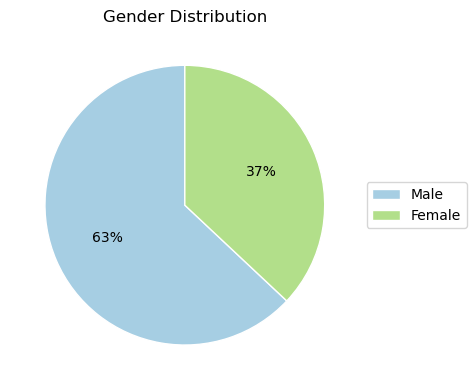

In [ ]:
import matplotlib.pyplot as plt

colors = ['#A6CEE3', '#B2DF8A']  

fig, ax = plt.subplots(figsize=(5, 4))

df["gender"].value_counts().reindex(["Male", "Female"]).plot.pie(
    autopct=lambda p: f'{p:.0f}%',  
    colors=colors,
    startangle=90,
    counterclock=True,
    wedgeprops={'edgecolor': 'white'},
    labels=None, 
    ax=ax
)

ax.legend(["Male", "Female"], loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title("Gender Distribution")
ax.set_ylabel("")
ax.set_aspect('equal') 

plt.tight_layout()
plt.savefig("figure1_gender_distribution.png", dpi=300, bbox_inches='tight')
plt.show()



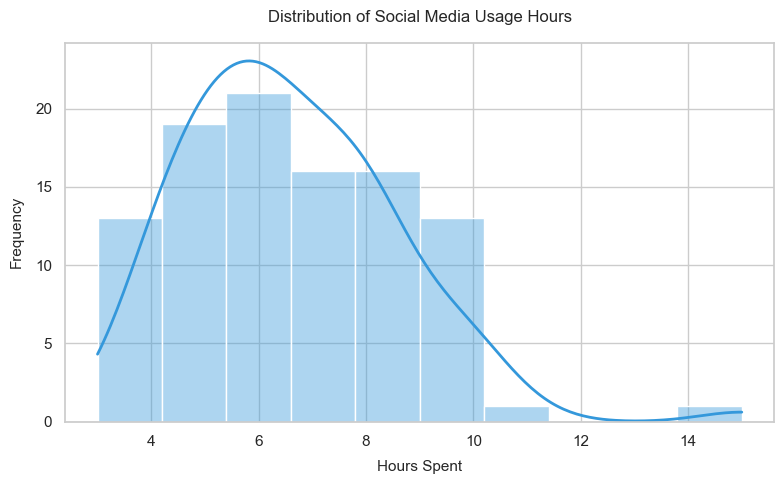

In [24]:
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df, 
    x="hours", 
    bins=10, 
    kde=True,                  
    color="#3498db",          
    alpha=0.4,                 
    edgecolor="white",         
    line_kws={"linewidth": 2}  
)

plt.xlabel("Hours Spent", fontsize=11, fontweight='regular', labelpad=8)
plt.ylabel("Frequency", fontsize=11, fontweight='regular', labelpad=8)
plt.title("Distribution of Social Media Usage Hours", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("social_media_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

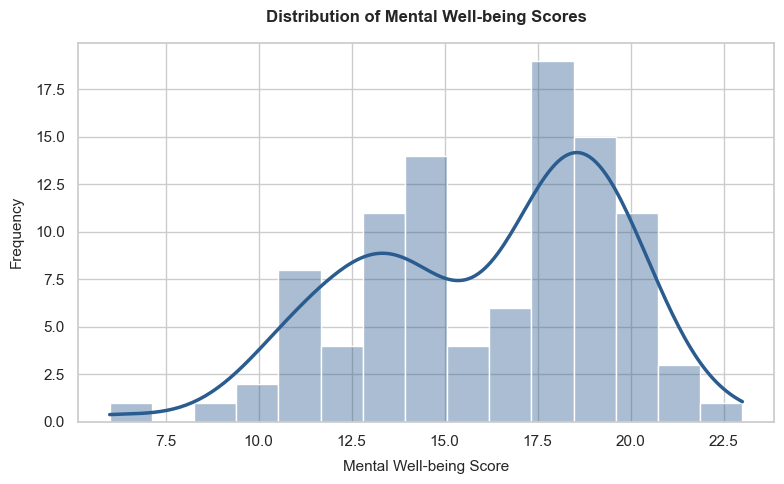

In [25]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.histplot(
    data=df, 
    x="wellbeing_score", 
    bins=15,                   
    kde=True,                 
    color="#2b5c8f",         
    alpha=0.4,                 
    edgecolor="white",         
    line_kws={"linewidth": 2.5, "color": "#1d3f66"} 
)

plt.xlabel("Mental Well-being Score", fontsize=11, labelpad=8)
plt.ylabel("Frequency", fontsize=11, labelpad=8)
plt.title("Distribution of Mental Well-being Scores", fontsize=12, pad=15, fontweight='bold')
plt.tight_layout()
plt.savefig("wellbeing_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

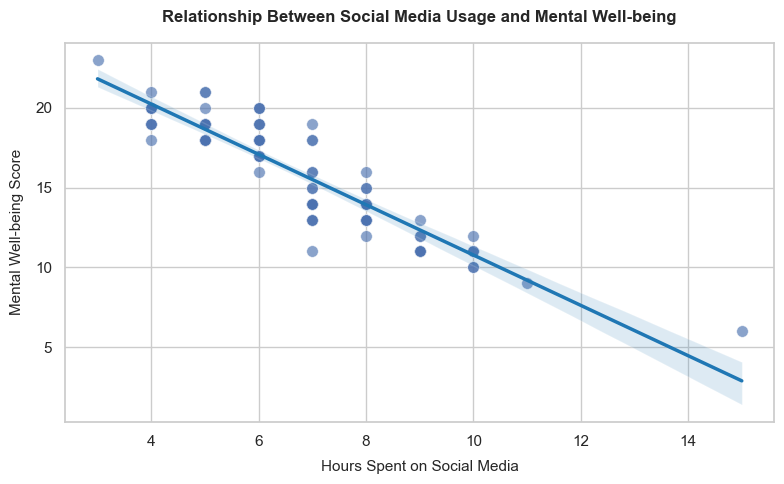

In [26]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df,
    x="hours",
    y="wellbeing_score",
    scatter_kws={"s": 70, "alpha": 0.65, "edgecolor": "white", "linewidths": 0.5}, 
    line_kws={"linewidth": 2.5, "color": "#1f77b4"},                             
    ci=95                                                                        
)

plt.xlabel("Hours Spent on Social Media", fontsize=11, labelpad=8)
plt.ylabel("Mental Well-being Score", fontsize=11, labelpad=8)
plt.title("Relationship Between Social Media Usage and Mental Well-being", fontsize=12, pad=15, fontweight='bold')
plt.tight_layout()
plt.savefig("relationship_scatter_plot.png", dpi=300, bbox_inches="tight")
plt.show()

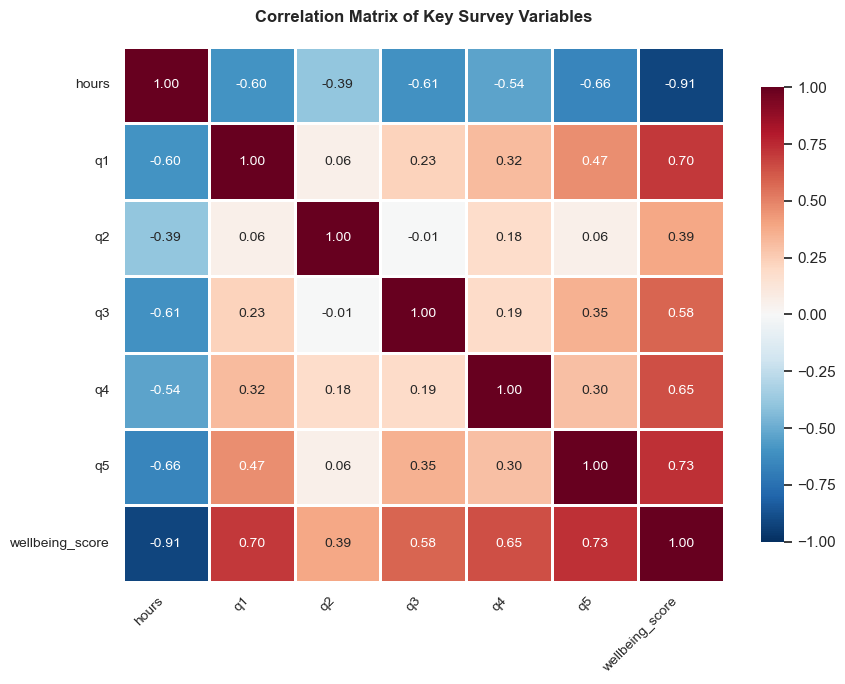

In [29]:
corr = df[[
    "hours",
    "q1",
    "q2",
    "q3",
    "q4",
    "q5",
    "wellbeing_score"
]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,                
    fmt=".2f",                  
    cmap="RdBu_r",              
    vmin=-1, vmax=1,             
    center=0,                   
    linewidths=0.75,             
    cbar_kws={"shrink": 0.85},   
    annot_kws={"size": 10}       
)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.title("Correlation Matrix of Key Survey Variables", fontsize=12, pad=18, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

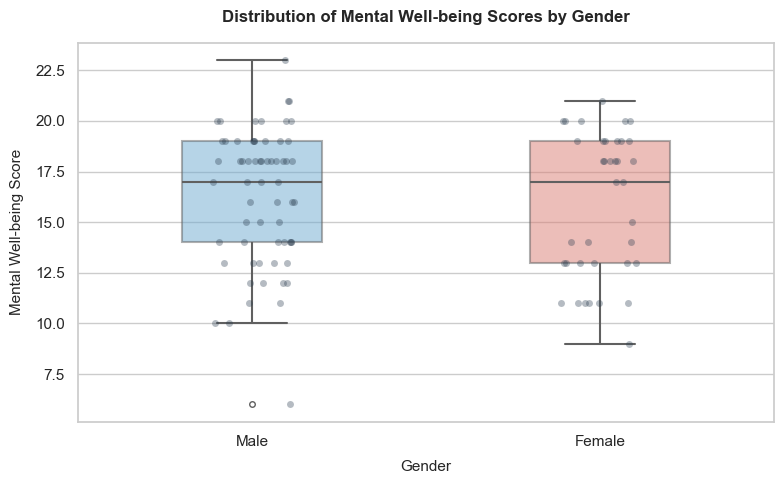

In [30]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
custom_palette = {"Male": "#5dade2", "Female": "#ec7063"} 
sns.boxplot(
    data=df,
    x="gender",
    y="wellbeing_score",
    hue="gender",                        
    palette=custom_palette,
    legend=False,                    
    width=0.4,                       
    linewidth=1.5,                      
    fliersize=4,                         
    boxprops=dict(alpha=0.5)           
)

sns.stripplot(
    data=df,
    x="gender",
    y="wellbeing_score",
    color="#2c3e50",                    
    alpha=0.35,                         
    jitter=0.12                        
)

plt.xlabel("Gender", fontsize=11, labelpad=8)
plt.ylabel("Mental Well-being Score", fontsize=11, labelpad=8)
plt.title("Distribution of Mental Well-being Scores by Gender", fontsize=12, pad=15, fontweight='bold')
plt.tight_layout()
plt.savefig("wellbeing_by_gender.png", dpi=300, bbox_inches="tight")
plt.show()

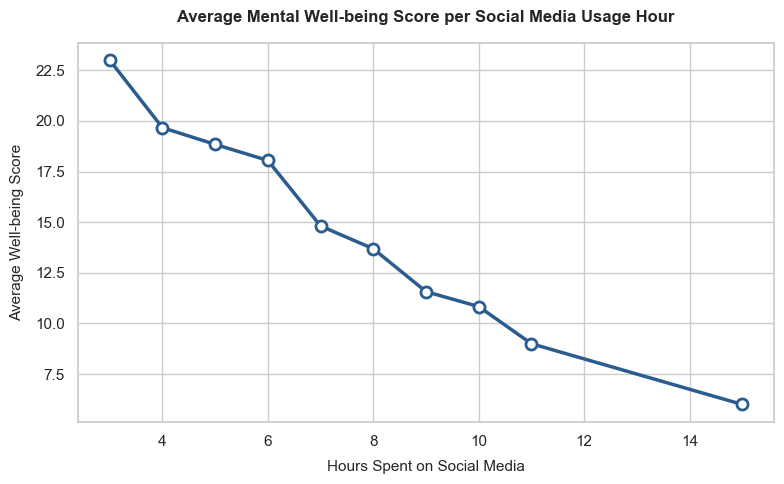

In [31]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
avg_scores = df.groupby("hours")["wellbeing_score"].mean()

plt.plot(
    avg_scores.index, 
    avg_scores.values, 
    color="#2b5c8f",         
    linewidth=2.5,           
    marker='o',                 
    markersize=8,             
    markerfacecolor='white',  
    markeredgewidth=2           
)

plt.xlabel("Hours Spent on Social Media", fontsize=11, labelpad=8)
plt.ylabel("Average Well-being Score", fontsize=11, labelpad=8)
plt.title("Average Mental Well-being Score per Social Media Usage Hour", fontsize=12, pad=15, fontweight='bold')
plt.tight_layout()
plt.savefig("average_wellbeing_line_graph.png", dpi=300, bbox_inches="tight")
plt.show()

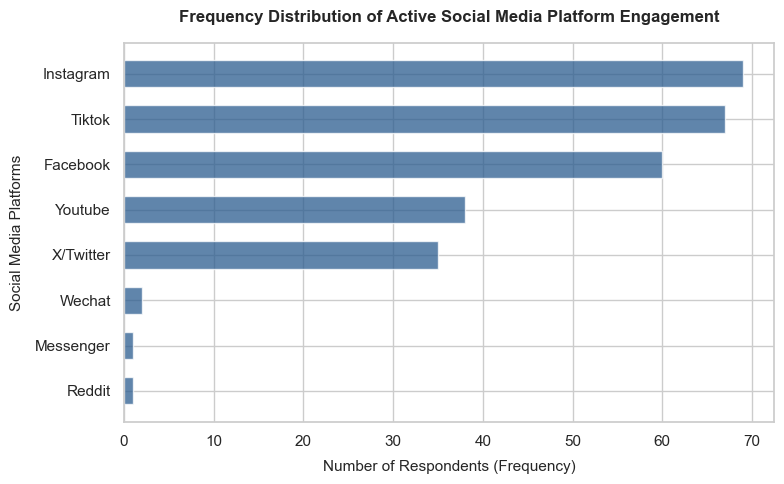

In [32]:
from collections import Counter

sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
platforms = []
for p in df["platforms"]:
    split_platforms = str(p).split(";")
    platforms.extend([item.strip() for item in split_platforms if item.strip()])
    
platform_count = Counter(platforms)
platform_df = pd.DataFrame(
    list(platform_count.items()), 
    columns=["Platform", "Count"]
).sort_values(by="Count", ascending=True)

plt.barh(
    platform_df["Platform"], 
    platform_df["Count"], 
    color="#2b5c8f",          
    alpha=0.75,               
    edgecolor="white",       
    height=0.6                
)

plt.xlabel("Number of Respondents (Frequency)", fontsize=11, labelpad=8)
plt.ylabel("Social Media Platforms", fontsize=11, labelpad=8)
plt.title("Frequency Distribution of Active Social Media Platform Engagement", fontsize=12, pad=15, fontweight='bold')
plt.tight_layout()
plt.savefig("appendix_platform_frequency.png", dpi=300, bbox_inches='tight')
plt.show()

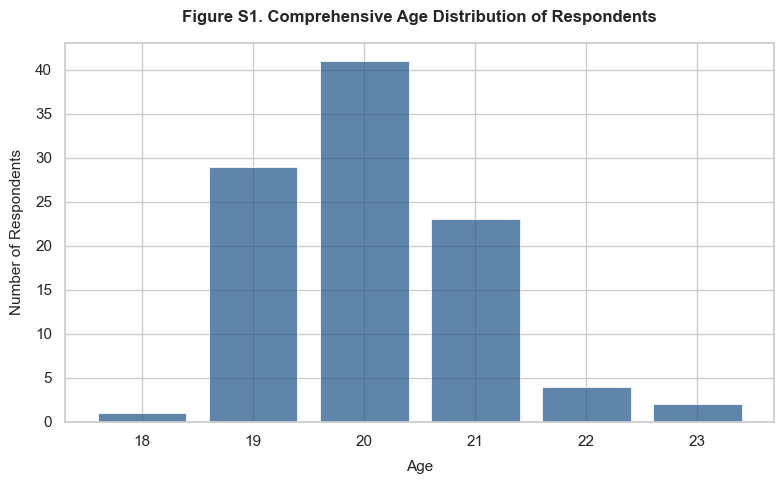

In [33]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))
age_counts = df["age"].value_counts().sort_index()
plt.bar(
    age_counts.index, 
    age_counts.values, 
    color="#2b5c8f",          
    alpha=0.75,          
    edgecolor="white",      
    linewidth=0.75
)

plt.xlabel("Age", fontsize=11, labelpad=8)
plt.ylabel("Number of Respondents", fontsize=11, labelpad=8)
plt.title("Figure S1. Comprehensive Age Distribution of Respondents", fontsize=12, pad=15, fontweight='bold')
plt.xticks(age_counts.index)
plt.tight_layout()
plt.savefig("appendix_age_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [34]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[17,19,21,23],
    labels=["18-19","20-21","22-23"]
)

frequency = df["age_group"].value_counts().sort_index()
percentage = df["age_group"].value_counts(normalize=True).sort_index() * 100

table_age = pd.DataFrame({
    "Frequency": frequency,
    "Percentage": percentage.round(2)
})

print(table_age)

           Frequency  Percentage
age_group                       
18-19             30        30.0
20-21             64        64.0
22-23              6         6.0


In [35]:
df['hours'].describe()

count    100.000000
mean       6.610000
std        1.968925
min        3.000000
25%        5.000000
50%        6.000000
75%        8.000000
max       15.000000
Name: hours, dtype: float64

In [37]:
df['wellbeing_score'].describe()

count    100.000000
mean      16.130000
std        3.398321
min        6.000000
25%       13.000000
50%       17.000000
75%       19.000000
max       23.000000
Name: wellbeing_score, dtype: float64

In [38]:
from scipy.stats import linregress

output = linregress(
    df["hours"],
    df["wellbeing_score"]
)

print(output)

LinregressResult(slope=np.float64(-1.578806117929076), intercept=np.float64(26.56590843951119), rvalue=np.float64(-0.9147314832418965), pvalue=np.float64(2.371454875169355e-40), stderr=np.float64(0.0704482856859805), intercept_stderr=np.float64(0.4856846036710709))
